#Detector de plagio mediante XGBoost

In [1]:
import os
import ast
import pandas as pd
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download(
    "ehsankhani/student-code-similarity-and-plagiarism-labels"
)

print("Dataset descargado en:")
print(path)

Using Colab cache for faster access to the 'student-code-similarity-and-plagiarism-labels' dataset.
Dataset descargado en:
/kaggle/input/student-code-similarity-and-plagiarism-labels


In [2]:
df = pd.read_csv(
    os.path.join(path, "cheating_dataset.csv")
)

print(df.columns.tolist())

df.head()

['File_1', 'File_2', 'Label']


,File_1,File_2,Label
0,submission1.py,submission2.py,1
1,submission1.py,submission3.py,0
2,submission1.py,submission4.py,1
3,submission1.py,submission5.py,0
4,submission2.py,submission3.py,0


In [3]:
import ast

class ASTAnonymizer(ast.NodeTransformer):

    # Variables
    def visit_Name(self, node):
        node.id = "VAR"
        return node

    # Parámetros de funciones
    def visit_arg(self, node):
        node.arg = "ARG"
        return node

    # Funciones
    def visit_FunctionDef(self, node):
        node.name = "FUNC"
        self.generic_visit(node)
        return node

    # Funciones async
    def visit_AsyncFunctionDef(self, node):
        node.name = "FUNC"
        self.generic_visit(node)
        return node

    # Clases
    def visit_ClassDef(self, node):
        node.name = "CLASS"
        self.generic_visit(node)
        return node

    # obj.attr -> obj.ATTR
    def visit_Attribute(self, node):
        node.attr = "ATTR"
        self.generic_visit(node)
        return node

    # Imports
    def visit_Import(self, node):
        for alias in node.names:
            alias.name = "MODULE"
            if alias.asname:
                alias.asname = "MODULE"
        return node

    # from x import y
    def visit_ImportFrom(self, node):
        node.module = "MODULE"

        for alias in node.names:
            alias.name = "MODULE"
            if alias.asname:
                alias.asname = "MODULE"

        return node

    # Strings, números, bools, None
    def visit_Constant(self, node):

        if isinstance(node.value, str):
            node.value = "STRING"

        elif isinstance(node.value, (int, float, complex)):
            node.value = 0

        elif isinstance(node.value, bool):
            node.value = True

        elif node.value is None:
            node.value = None

        return node

In [4]:
def process_file_to_ast(file_path):

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            source = f.read()

        tree = ast.parse(source)

        anonymizer = ASTAnonymizer()
        tree = anonymizer.visit(tree)

        ast.fix_missing_locations(tree)

        return ast.dump(tree)

    except Exception as e:
        print(f"Error procesando {file_path}: {e}")
        return None

In [5]:
def build_final_dataset(dataset_path):

    print("[*] Loading labeled dataset...")

    csv_path = os.path.join(
        dataset_path,
        "cheating_dataset.csv"
    )

    df = pd.read_csv(csv_path)

    print("Columnas encontradas:")
    print(df.columns.tolist())

    ast_cache = {}

    def get_cached_ast(file_name):

        if file_name not in ast_cache:

            full_path = os.path.join(
                dataset_path,
                file_name
            )

            ast_cache[file_name] = process_file_to_ast(
                full_path
            )

        return ast_cache[file_name]

    print("[*] Parsing source files into ASTs...")

    df["AST_1"] = df["File_1"].apply(
        get_cached_ast
    )

    df["AST_2"] = df["File_2"].apply(
        get_cached_ast
    )

    initial_len = len(df)

    df_cleaned = (
        df
        .dropna(subset=["AST_1", "AST_2"])
        .reset_index(drop=True)
    )

    output_file = "ast_dataset.csv"

    df_cleaned.to_csv(
        output_file,
        index=False
    )

    print(
        f"[+] Success! {len(df_cleaned)}/{initial_len} pairs saved."
    )

    print(f"Saved as: {output_file}")

    return df_cleaned

In [6]:
df_ast = build_final_dataset(path)

df_ast.head()

[*] Loading labeled dataset...
Columnas encontradas:
['File_1', 'File_2', 'Label']
[*] Parsing source files into ASTs...
[+] Success! 293/293 pairs saved.
Saved as: ast_dataset.csv


,File_1,File_2,Label,AST_1,AST_2
0,submission1.py,submission2.py,1,"Module(body=[FunctionDef(name='FUNC', args=arg...","Module(body=[FunctionDef(name='FUNC', args=arg..."
1,submission1.py,submission3.py,0,"Module(body=[FunctionDef(name='FUNC', args=arg...","Module(body=[FunctionDef(name='FUNC', args=arg..."
2,submission1.py,submission4.py,1,"Module(body=[FunctionDef(name='FUNC', args=arg...","Module(body=[FunctionDef(name='FUNC', args=arg..."
3,submission1.py,submission5.py,0,"Module(body=[FunctionDef(name='FUNC', args=arg...","Module(body=[FunctionDef(name='FUNC', args=arg..."
4,submission2.py,submission3.py,0,"Module(body=[FunctionDef(name='FUNC', args=arg...","Module(body=[FunctionDef(name='FUNC', args=arg..."


#Extraer columnas del ast

In [7]:
import pandas as pd
import numpy as np
import difflib
import re
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [8]:
def extract_features():

    df = pd.read_csv("ast_dataset.csv")

    df = (
        df
        .dropna(subset=["AST_1", "AST_2"])
        .reset_index(drop=True)
    )

    print(f"Procesando {len(df)} pares...")

    def get_sequence_similarity(str1, str2):
        return difflib.SequenceMatcher(
            None,
            str1,
            str2
        ).ratio()

    df["seq_similarity"] = df.apply(
        lambda r: get_sequence_similarity(
            r["AST_1"],
            r["AST_2"]
        ),
        axis=1
    )

    def get_length_ratio(str1, str2):

        len1 = len(str1)
        len2 = len(str2)

        if max(len1, len2) == 0:
            return 0

        return min(len1, len2) / max(len1, len2)

    df["length_ratio"] = df.apply(
        lambda r: get_length_ratio(
            r["AST_1"],
            r["AST_2"]
        ),
        axis=1
    )

    vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3)
    )

    all_asts = (
        df["AST_1"].tolist()
        + df["AST_2"].tolist()
    )

    vectorizer.fit(all_asts)

    def get_cosine_sim(row):

        vecs = vectorizer.transform([
            row["AST_1"],
            row["AST_2"]
        ])

        return cosine_similarity(
            vecs[0],
            vecs[1]
        )[0][0]

    df["cosine_similarity"] = df.apply(
        get_cosine_sim,
        axis=1
    )

    def extract_node_types(ast_string):

        return re.findall(
            r'([A-Za-z_][A-Za-z0-9_]*)\(',
            ast_string
        )

    def get_jaccard_similarity(s1, s2):

        nodes1 = set(extract_node_types(s1))
        nodes2 = set(extract_node_types(s2))

        if not nodes1 and not nodes2:
            return 1.0

        return (
            len(nodes1 & nodes2)
            / len(nodes1 | nodes2)
        )

    df["jaccard_similarity"] = df.apply(
        lambda r: get_jaccard_similarity(
            r["AST_1"],
            r["AST_2"]
        ),
        axis=1
    )

    def node_frequency_similarity(s1, s2):

        c1 = Counter(extract_node_types(s1))
        c2 = Counter(extract_node_types(s2))

        all_nodes = set(c1) | set(c2)

        numerator = 0
        denominator = 0

        for node in all_nodes:

            numerator += min(
                c1.get(node, 0),
                c2.get(node, 0)
            )

            denominator += max(
                c1.get(node, 0),
                c2.get(node, 0)
            )

        if denominator == 0:
            return 1.0

        return numerator / denominator

    df["node_frequency_similarity"] = df.apply(
        lambda r: node_frequency_similarity(
            r["AST_1"],
            r["AST_2"]
        ),
        axis=1
    )

    def get_max_depth(ast_string):

        current_depth = 0
        max_depth = 0

        for char in ast_string:

            if char in "([":
                current_depth += 1
                max_depth = max(
                    max_depth,
                    current_depth
                )

            elif char in ")]":
                current_depth -= 1

        return max_depth

    df["depth_difference"] = df.apply(
        lambda r: abs(
            get_max_depth(r["AST_1"])
            - get_max_depth(r["AST_2"])
        ),
        axis=1
    )
    df["max_depth_1"] = df["AST_1"].apply(
    get_max_depth
    )

    df["max_depth_2"] = df["AST_2"].apply(
        get_max_depth
    )

    def count_nodes(ast_string):

        return len(
            extract_node_types(ast_string)
        )

    df["node_count_1"] = df["AST_1"].apply(
        count_nodes
    )

    df["node_count_2"] = df["AST_2"].apply(
        count_nodes
    )

    df["node_count_difference"] = (
        df["node_count_1"]
        - df["node_count_2"]
    ).abs()

    feature_cols = [

      "seq_similarity",
      "length_ratio",
      "cosine_similarity",

      "jaccard_similarity",
      "node_frequency_similarity",

      "depth_difference",

      "node_count_1",
      "node_count_2",
      "node_count_difference",

      "max_depth_1",
      "max_depth_2"
    ]

    final_cols = [
        "File_1",
        "File_2"
    ] + feature_cols + [
        "Label"
    ]

    df_final = df[final_cols]

    df_final.to_csv(
        "fixed_dataset.csv",
        index=False
    )

    print("\nDataset generado:")
    print(df_final.head())

    print("\nFeatures:")
    print(feature_cols)

    return df_final

In [9]:
df = extract_features()

Procesando 293 pares...

Dataset generado:
           File_1          File_2  seq_similarity  length_ratio  \
0  submission1.py  submission2.py        1.000000      1.000000   
1  submission1.py  submission3.py        0.990354      1.000000   
2  submission1.py  submission4.py        0.864865      0.793367   
3  submission1.py  submission5.py        0.988764      0.996795   
4  submission2.py  submission3.py        0.990354      1.000000   

   cosine_similarity  jaccard_similarity  node_frequency_similarity  \
0           1.000000            1.000000                   1.000000   
1           0.835374            0.800000                   0.846154   
2           0.865462            0.818182                   0.705882   
3           0.815256            0.800000                   0.846154   
4           0.835374            0.800000                   0.846154   

   depth_difference  node_count_1  node_count_2  node_count_difference  \
0                 0            12            12      

#Modelo

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [11]:
df = pd.read_csv("fixed_dataset.csv")
df.head()

,File_1,File_2,seq_similarity,length_ratio,cosine_similarity,jaccard_similarity,node_frequency_similarity,depth_difference,node_count_1,node_count_2,node_count_difference,max_depth_1,max_depth_2,Label
0,submission1.py,submission2.py,1.000000,1.000000,1.000000,1.000000,1.000000,0,12,12,0,8,8,1
1,submission1.py,submission3.py,0.990354,1.000000,0.835374,0.800000,0.846154,0,12,12,0,8,8,0
2,submission1.py,submission4.py,0.864865,0.793367,0.865462,0.818182,0.705882,0,12,17,5,8,8,1
3,submission1.py,submission5.py,0.988764,0.996795,0.815256,0.800000,0.846154,0,12,12,0,8,8,0
4,submission2.py,submission3.py,0.990354,1.000000,0.835374,0.800000,0.846154,0,12,12,0,8,8,0


In [12]:
print("Dimensiones del dataset:", df.shape)
df.info()
df["Label"].value_counts()

Dimensiones del dataset: (293, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   File_1                     293 non-null    object 
 1   File_2                     293 non-null    object 
 2   seq_similarity             293 non-null    float64
 3   length_ratio               293 non-null    float64
 4   cosine_similarity          293 non-null    float64
 5   jaccard_similarity         293 non-null    float64
 6   node_frequency_similarity  293 non-null    float64
 7   depth_difference           293 non-null    int64  
 8   node_count_1               293 non-null    int64  
 9   node_count_2               293 non-null    int64  
 10  node_count_difference      293 non-null    int64  
 11  max_depth_1                293 non-null    int64  
 12  max_depth_2                293 non-null    int64  
 13  Label          

,count
Label,
0,193
1,100


In [13]:
#Variables que se usarán para entrenar al modelo
X = df[
    [
        "length_ratio",
        "seq_similarity",
        "cosine_similarity",
        "jaccard_similarity",
        "depth_difference",
        "node_frequency_similarity",
        "node_count_difference",
        "max_depth_1",
        "max_depth_2"
    ]
]

y = df["Label"]

##Dividir dataset

In [14]:
# Dividir Dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.45,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (161, 9)
Validation: (66, 9)
Test: (66, 9)


In [15]:
# Escalar Datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import joblib

#Balanceo de clases

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print(f"Negativos: {negativos}")
print(f"Positivos: {positivos}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

param_grid = {

    "n_estimators": [
        150,
        160
    ],

    "learning_rate": [
        0.03
    ],

    "max_depth": [
        5,
    ],

    "subsample": [
        1.0
    ],

    "colsample_bytree": [
        1.0
    ],

    "min_child_weight": [
        2,
    ],

    "gamma": [
        0.20,
        0.25
    ],

    "reg_alpha": [
        0,
        0.005,
    ],

    "reg_lambda": [
        3,
        3.5,
    ],

    "max_delta_step": [
        0,
        2
    ],

    "grow_policy": [
        "depthwise",
        "lossguide"
    ]
}

best_model = None
best_params = None
best_threshold = 0.5
best_f1 = -1

results = []

total_models = (
    len(param_grid["n_estimators"])
    * len(param_grid["learning_rate"])
    * len(param_grid["max_depth"])
    * len(param_grid["subsample"])
    * len(param_grid["colsample_bytree"])
    * len(param_grid["min_child_weight"])
    * len(param_grid["gamma"])
    * len(param_grid["reg_alpha"])
    * len(param_grid["reg_lambda"])
    * len(param_grid["max_delta_step"])
    * len(param_grid["grow_policy"])
)

print(f"\nEvaluando {total_models:,} modelos...\n")

counter = 0

for n_estimators in param_grid["n_estimators"]:

    for learning_rate in param_grid["learning_rate"]:

        for max_depth in param_grid["max_depth"]:

            for subsample in param_grid["subsample"]:

                for colsample in param_grid["colsample_bytree"]:

                    for min_child_weight in param_grid["min_child_weight"]:

                        for gamma in param_grid["gamma"]:

                            for reg_alpha in param_grid["reg_alpha"]:

                                for reg_lambda in param_grid["reg_lambda"]:

                                    for max_delta_step in param_grid["max_delta_step"]:

                                        for grow_policy in param_grid["grow_policy"]:

                                            counter += 1

                                            print(
                                                f"Modelo "
                                                f"{counter:,}/{total_models:,}"
                                            )

                                            model = XGBClassifier(

                                                n_estimators=n_estimators,
                                                learning_rate=learning_rate,
                                                max_depth=max_depth,

                                                subsample=subsample,
                                                colsample_bytree=colsample,

                                                min_child_weight=min_child_weight,

                                                gamma=gamma,

                                                reg_alpha=reg_alpha,
                                                reg_lambda=reg_lambda,

                                                max_delta_step=max_delta_step,
                                                grow_policy=grow_policy,

                                                scale_pos_weight=scale_pos_weight,

                                                random_state=42,

                                                eval_metric="logloss",

                                                tree_method="hist",

                                                n_jobs=-1
                                            )

                                            model.fit(
                                                X_train,
                                                y_train
                                            )

                                            val_probs = (
                                                model.predict_proba(
                                                    X_val
                                                )[:, 1]
                                            )

                                            local_best_f1 = -1
                                            local_best_threshold = 0.5

                                            for threshold in np.arange(
                                                0.45,
                                                0.66,
                                                0.005
                                            ):

                                                val_pred = (
                                                    val_probs >= threshold
                                                ).astype(int)

                                                f1 = f1_score(
                                                    y_val,
                                                    val_pred
                                                )

                                                if f1 > local_best_f1:

                                                    local_best_f1 = f1
                                                    local_best_threshold = threshold

                                            results.append({

                                                "n_estimators": n_estimators,
                                                "learning_rate": learning_rate,
                                                "max_depth": max_depth,

                                                "subsample": subsample,
                                                "colsample_bytree": colsample,

                                                "min_child_weight": min_child_weight,

                                                "gamma": gamma,

                                                "reg_alpha": reg_alpha,
                                                "reg_lambda": reg_lambda,

                                                "max_delta_step": max_delta_step,
                                                "grow_policy": grow_policy,

                                                "threshold": local_best_threshold,

                                                "validation_f1": local_best_f1
                                            })

                                            if local_best_f1 > best_f1:

                                                best_f1 = local_best_f1

                                                best_model = model

                                                best_threshold = (
                                                    local_best_threshold
                                                )

                                                best_params = {

                                                    "n_estimators": n_estimators,
                                                    "learning_rate": learning_rate,
                                                    "max_depth": max_depth,

                                                    "subsample": subsample,
                                                    "colsample_bytree": colsample,

                                                    "min_child_weight": min_child_weight,

                                                    "gamma": gamma,

                                                    "reg_alpha": reg_alpha,
                                                    "reg_lambda": reg_lambda,

                                                    "max_delta_step": max_delta_step,
                                                    "grow_policy": grow_policy
                                                }

print("\n=== MEJOR MODELO ===")
print(best_params)

print(
    f"Mejor threshold: "
    f"{best_threshold:.3f}"
)

print(
    f"Validation F1: "
    f"{best_f1:.6f}"
)

joblib.dump(
    {
        "model": best_model,
        "threshold": best_threshold,
        "params": best_params,
        "validation_f1": best_f1
    },
    "best_xgboost_model.pkl"
)

print(
    "\nModelo guardado como:"
    "\nbest_xgboost_model.pkl"
)

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "validation_f1",
        ascending=False
    )
)

display(results_df.head(20))

Negativos: 106
Positivos: 55
scale_pos_weight: 1.927

Evaluando 64 modelos...

Modelo 1/64
Modelo 2/64
Modelo 3/64
Modelo 4/64
Modelo 5/64
Modelo 6/64
Modelo 7/64
Modelo 8/64
Modelo 9/64
Modelo 10/64
Modelo 11/64
Modelo 12/64
Modelo 13/64
Modelo 14/64
Modelo 15/64
Modelo 16/64
Modelo 17/64
Modelo 18/64
Modelo 19/64
Modelo 20/64
Modelo 21/64
Modelo 22/64
Modelo 23/64
Modelo 24/64
Modelo 25/64
Modelo 26/64
Modelo 27/64
Modelo 28/64
Modelo 29/64
Modelo 30/64
Modelo 31/64
Modelo 32/64
Modelo 33/64
Modelo 34/64
Modelo 35/64
Modelo 36/64
Modelo 37/64
Modelo 38/64
Modelo 39/64
Modelo 40/64
Modelo 41/64
Modelo 42/64
Modelo 43/64
Modelo 44/64
Modelo 45/64
Modelo 46/64
Modelo 47/64
Modelo 48/64
Modelo 49/64
Modelo 50/64
Modelo 51/64
Modelo 52/64
Modelo 53/64
Modelo 54/64
Modelo 55/64
Modelo 56/64
Modelo 57/64
Modelo 58/64
Modelo 59/64
Modelo 60/64
Modelo 61/64
Modelo 62/64
Modelo 63/64
Modelo 64/64

=== MEJOR MODELO ===
{'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 5, 'subsample': 1.

,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda,max_delta_step,grow_policy,threshold,validation_f1
0,150,0.03,5,1.0,1.0,2,0.20,0.000,3.0,0,depthwise,0.490,0.818182
1,150,0.03,5,1.0,1.0,2,0.20,0.000,3.0,0,lossguide,0.490,0.818182
2,150,0.03,5,1.0,1.0,2,0.20,0.000,3.0,2,depthwise,0.490,0.818182
3,150,0.03,5,1.0,1.0,2,0.20,0.000,3.0,2,lossguide,0.490,0.818182
11,150,0.03,5,1.0,1.0,2,0.20,0.005,3.0,2,lossguide,0.500,0.818182
10,150,0.03,5,1.0,1.0,2,0.20,0.005,3.0,2,depthwise,0.500,0.818182
9,150,0.03,5,1.0,1.0,2,0.20,0.005,3.0,0,lossguide,0.485,0.818182
8,150,0.03,5,1.0,1.0,2,0.20,0.005,3.0,0,depthwise,0.485,0.818182
30,150,0.03,5,1.0,1.0,2,0.25,0.005,3.5,2,depthwise,0.490,0.818182
31,150,0.03,5,1.0,1.0,2,0.25,0.005,3.5,2,lossguide,0.490,0.818182


##Gráfica del Mejor modelo

Se reentrena para sacar gráficas de la evolución del entrenamiento.

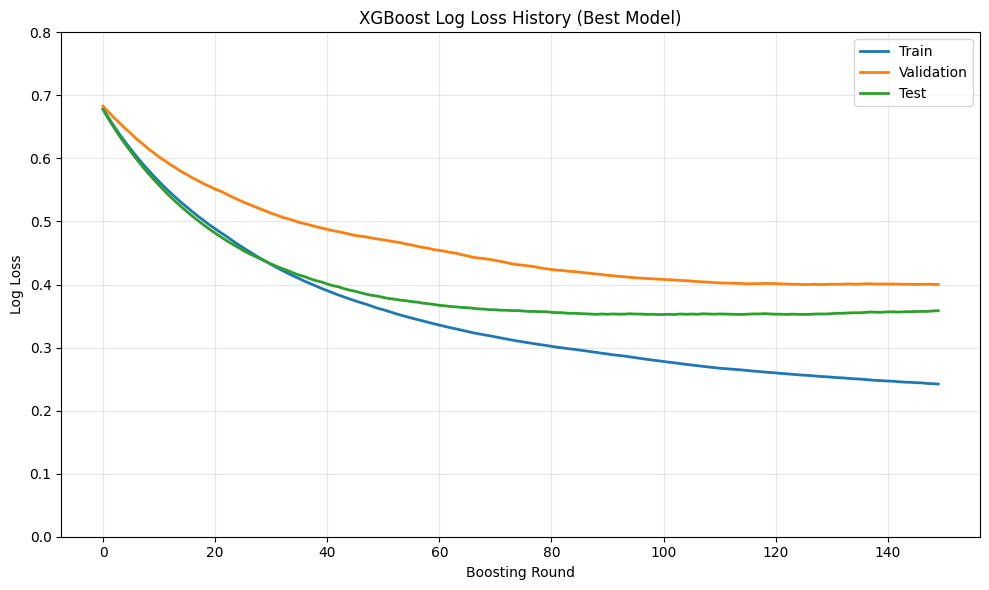

In [17]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

best_model = XGBClassifier(

    n_estimators=150,
    learning_rate=0.03,
    max_depth=5,

    subsample=1.0,
    colsample_bytree=1.0,

    min_child_weight=2,

    gamma=0.20,

    reg_alpha=0.0,
    reg_lambda=3.0,

    max_delta_step=0,

    grow_policy="depthwise",

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss",

    tree_method="hist",

    n_jobs=-1
)

best_model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val),
        (X_test, y_test)
    ],
    verbose=False
)

history = best_model.evals_result()

train_loss = history["validation_0"]["logloss"]
val_loss   = history["validation_1"]["logloss"]
test_loss  = history["validation_2"]["logloss"]

plt.figure(figsize=(10, 6))

plt.plot(
    train_loss,
    label="Train",
    linewidth=2
)

plt.plot(
    val_loss,
    label="Validation",
    linewidth=2
)

plt.plot(
    test_loss,
    label="Test",
    linewidth=2
)

plt.ylim(0, .8)

plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Log Loss History (Best Model)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
train_probs = best_model.predict_proba(X_train)[:, 1]
val_probs = best_model.predict_proba(X_val)[:, 1]
test_probs = best_model.predict_proba(X_test)[:, 1]

train_pred = (
    train_probs >= best_threshold
).astype(int)

val_pred = (
    val_probs >= best_threshold
).astype(int)

test_pred = (
    test_probs >= best_threshold
).astype(int)

##Área bajo la curva RoC AUC

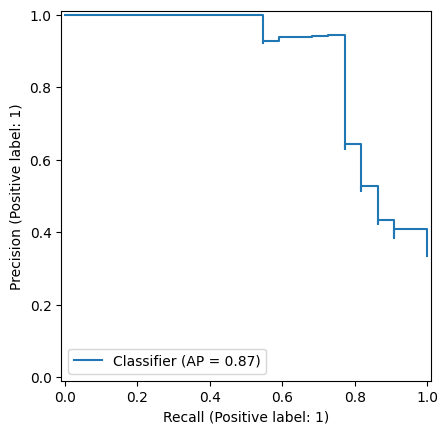

In [19]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probs
)
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, test_probs)

np.float64(0.8739669421487604)

---

##Reporte de las métricas obtenidas

In [21]:
train_pred = best_model.predict(X_train)
val_pred = best_model.predict(X_val)
test_pred = best_model.predict(X_test)

In [22]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

In [23]:
train_metrics = get_metrics(y_train, train_pred)
validation_metrics = get_metrics(y_val, val_pred)
test_metrics = get_metrics(y_test, test_pred)

comparison_df = pd.DataFrame({
    "Train": train_metrics,
    "Validation": validation_metrics,
    "Test": test_metrics
})

comparison_df

,Train,Validation,Test
Accuracy,0.937888,0.863636,0.893939
Precision,0.881356,0.850000,0.894737
Recall,0.945455,0.739130,0.772727
F1-score,0.912281,0.790698,0.829268


In [24]:
print(
    classification_report(
        y_val,
        val_pred,
        target_names=["No Plagiarism", "Plagiarism"],
        zero_division=0
    )
)

               precision    recall  f1-score   support

No Plagiarism       0.87      0.93      0.90        43
   Plagiarism       0.85      0.74      0.79        23

     accuracy                           0.86        66
    macro avg       0.86      0.83      0.84        66
 weighted avg       0.86      0.86      0.86        66



In [25]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["No Plagiarism", "Plagiarism"],
        zero_division=0
    )
)

               precision    recall  f1-score   support

No Plagiarism       0.89      0.95      0.92        44
   Plagiarism       0.89      0.77      0.83        22

     accuracy                           0.89        66
    macro avg       0.89      0.86      0.88        66
 weighted avg       0.89      0.89      0.89        66



##Matrices de confusión

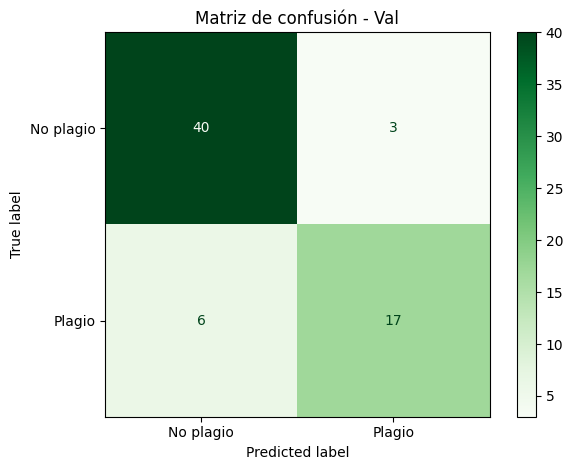

In [26]:
cm_val = confusion_matrix(y_val, val_pred)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=['No plagio', 'Plagio']
)

disp_test.plot(cmap='Greens', values_format='d')
plt.title('Matriz de confusión - Val')
plt.tight_layout()
plt.show()

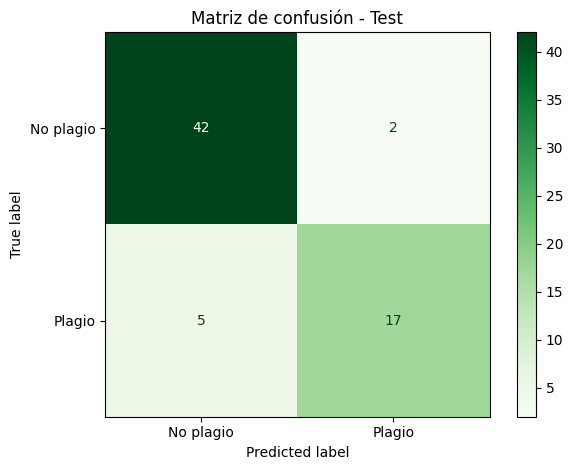

In [27]:
cm_test = confusion_matrix(y_test, test_pred)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['No plagio', 'Plagio']
)

disp_test.plot(cmap='Greens', values_format='d')
plt.title('Matriz de confusión - Test')
plt.tight_layout()
plt.show()

##Qué tanto ayudaron a mejorar el modelo

In [28]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
1             seq_similarity    0.394144
2          cosine_similarity    0.191860
5  node_frequency_similarity    0.110956
3         jaccard_similarity    0.068843
0               length_ratio    0.066217
7                max_depth_1    0.056833
8                max_depth_2    0.050074
6      node_count_difference    0.041658
4           depth_difference    0.019417


##Cuántas veces se emplearon para tomar decisiones en los árboles

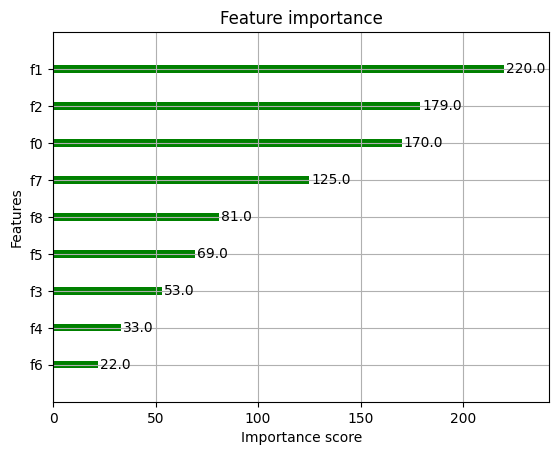

In [29]:
from xgboost import plot_importance

plot_importance(best_model, color="green")
plt.show()